In [46]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:

import torch
torch.cuda.empty_cache()

In [48]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/SS/')

In [49]:
import torch, torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
import time
import os
import cv2
from dataPreparation import dataPrep
from imutils import paths
from sklearn.model_selection import train_test_split
from torch.nn import Module
from FCN import FCN
#from unet_orig_v1 import UNet
from torch.nn import CrossEntropyLoss, BCEWithLogitsLoss
from torch.optim import Adam
from tqdm import tqdm
from earlyStopping import EarlyStopping

In [50]:
dataset_path = "/content/drive/My Drive/Colab Notebooks/SS/drone/dataset/semantic_drone_dataset/"
image_path=dataset_path+'original_images/'
masked_path = dataset_path+ 'label_images_semantic/'
rgb_mask_path='/content/drive/My Drive/Colab Notebooks/SS/drone/RGB_color_image_masks/RGB_color_image_masks'
TEST_SPLIT = 0.10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = True if DEVICE == "cuda" else False

In [51]:
INIT_LR = 0.01
NUM_EPOCHS = 500
BATCH_SIZE = 3

INPUT_IMAGE_WIDTH = 6000
INPUT_IMAGE_HEIGHT = 4000

BASE_OUTPUT ="/content/drive/My Drive/Colab Notebooks/SS/drone/output"

MODEL_PATH = os.path.join(BASE_OUTPUT, "Unet_BN.pth")
PLOT_PATH = os.path.sep.join([BASE_OUTPUT, "Train_Test_Plot.png"])
TEST_PATHS = os.path.sep.join([BASE_OUTPUT, "test_path.txt"])

In [52]:
imagePaths = sorted(list(paths.list_images(image_path)))
maskPaths = sorted(list(paths.list_images(masked_path)))

X_trainval,X_test, y_trainval, y_test = train_test_split(imagePaths, maskPaths,test_size=TEST_SPLIT, random_state=1)
X_train, X_val, y_train,y_val = train_test_split(X_trainval,y_trainval, test_size=0.2, random_state=1)

#(trainImages, testImages) = split[:2]
#(trainMasks, testMasks) = split[2:]

print("[INFO] saving testing image paths...")
f = open(TEST_PATHS, "w")
f.write("\n".join(X_test))
f.close()

[INFO] saving testing image paths...


In [53]:
len(X_val)

72

In [54]:
input_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((800,1200)),  # Resize the input image to (height=256, width=384)
        transforms.ToTensor()
        #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((800,1200)),  # Resize the mask to the same size as the input image
    transforms.ToTensor()
])

In [55]:
train = dataPrep(imagePaths=X_train, maskPaths=y_train, input_transform=input_transform, mask_transform=mask_transform,n_class=23)
test = dataPrep(imagePaths=X_val, maskPaths=y_val, input_transform=input_transform, mask_transform=mask_transform,n_class=23)


trainLoader = DataLoader(train, shuffle=True,batch_size=BATCH_SIZE, pin_memory=PIN_MEMORY)

testLoader = DataLoader(test, shuffle=True,batch_size=BATCH_SIZE, pin_memory=PIN_MEMORY)


In [56]:
# -*- coding: utf-8 -*-
"""
"""
from torch.nn import ConvTranspose2d
from torch.nn import Conv2d
from torch.nn import MaxPool2d
from torch.nn import Module
from torch.nn import ModuleList
from torch.nn import ReLU
from torchvision.transforms import CenterCrop
from torch.nn import functional as F
import torch,torchvision

class Encoder(torch.nn.Module):
    def __init__(self):
        super().__init__()


        self.conv1 = torch.nn.Conv2d(3, 16, 3,padding=1)
        self.conv2 = torch.nn.Conv2d(16, 16, 3,padding=1)
        self.bn1=torch.nn.BatchNorm2d(16)

        self.conv3 = torch.nn.Conv2d(16, 32, 3,padding=1)
        self.conv4 = torch.nn.Conv2d(32, 32, 3,padding=1)
        self.bn2=torch.nn.BatchNorm2d(32)

        self.conv5 = torch.nn.Conv2d(32, 64, 3,padding=1)
        self.conv6 = torch.nn.Conv2d(64, 64, 3,padding=1)
        self.bn3=torch.nn.BatchNorm2d(64)


        self.conv7 = torch.nn.Conv2d(64, 128, 3,padding=1)
        self.conv8 = torch.nn.Conv2d(128, 128, 3,padding=1)
        self.bn4=torch.nn.BatchNorm2d(128)


        self.conv9 = torch.nn.Conv2d(128, 256, 3,padding=1)
        self.conv10 = torch.nn.Conv2d(256, 256, 3,padding=1)
        self.bn5=torch.nn.BatchNorm2d(256)

        #self.conv7 = torch.nn.Conv2d(256, 512, 3,padding=1)
        #self.conv8 = torch.nn.Conv2d(512, 512, 3,padding=1)

        self.dropout1 = torch.nn.Dropout(p = 0.1)
        self.dropout3 = torch.nn.Dropout(p = 0.3)

        self.pool = torch.nn.MaxPool2d(2)

    def forward(self, x):
        ftrs = []
        x = self.conv1(x)
        x= self.bn1(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout1(x)
        x = self.conv2(x)
        x= self.bn1(x)
        x = torch.nn.functional .relu(x)
        ftrs.append(x)
        x = self.pool(x)


        x = self.conv3(x)
        x= self.bn2(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout1(x)
        x = self.conv4(x)
        x= self.bn2(x)
        x = torch.nn.functional .relu(x)
        ftrs.append(x)
        x = self.pool(x)


        x = self.conv5(x)
        x= self.bn3(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout1(x)
        x = self.conv6(x)
        x= self.bn3(x)
        x = torch.nn.functional .relu(x)
        ftrs.append(x)
        x = self.pool(x)


        x = self.conv7(x)
        x= self.bn4(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout1(x)
        x = self.conv8(x)
        x= self.bn4(x)
        x = torch.nn.functional .relu(x)
        ftrs.append(x)
        x = self.pool(x)


        x = self.conv9(x)
        x= self.bn5(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout3(x)
        x = self.conv10(x)
        x= self.bn5(x)
        x = torch.nn.functional .relu(x)
        ftrs.append(x)
        #x = self.pool(x)


        return ftrs


class Decoder(torch.nn.Module):
    def __init__(self):
        super().__init__()

        #self.convTr0 = torch.nn.ConvTranspose2d(512, 256, kernel_size=2,stride=2)
        #self.conv0= torch.nn.Conv2d(512, 256, 3,padding=1)

        self.convTr1 = torch.nn.ConvTranspose2d(256, 128, kernel_size=2,stride=2)
        self.conv1 = torch.nn.Conv2d(256, 128, 3,padding=1)
        self.conv1_1 = torch.nn.Conv2d(128, 128, 3,padding=1)
        self.bn1=torch.nn.BatchNorm2d(128)


        self.convTr2 = torch.nn.ConvTranspose2d(128, 64, kernel_size=2,stride=2)
        self.conv2 = torch.nn.Conv2d(128, 64, 3,padding=1)
        self.conv2_2 = torch.nn.Conv2d(64, 64, 3,padding=1)
        self.bn2=torch.nn.BatchNorm2d(64)

        self.convTr3 = torch.nn.ConvTranspose2d(64, 32, kernel_size=2,stride=2)
        self.conv3 = torch.nn.Conv2d(64, 32, 3,padding=1)
        self.conv3_3 = torch.nn.Conv2d(32, 32, 3,padding=1)
        self.bn3=torch.nn.BatchNorm2d(32)

        self.convTr4 = torch.nn.ConvTranspose2d(32, 16, kernel_size=2,stride=2)
        self.conv4 = torch.nn.Conv2d(32, 16, 3,padding=1)
        self.conv4_4 = torch.nn.Conv2d(16, 16, 3,padding=1)
        self.bn4=torch.nn.BatchNorm2d(16)

        self.dropout1 = torch.nn.Dropout(p = 0.1)
        self.dropout2 = torch.nn.Dropout(p = 0.2)



    def forward(self, x, encoder_features):


        x = self.convTr1(x)
        x = torch.nn.functional .relu(x)
        #enc_ftrs = self.crop(encoder_features[0], x)
        x        = torch.cat([x, encoder_features[0]], dim=1)
        x        = self.conv1(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout1(x)
        x        = self.conv1_1(x)
        x = torch.nn.functional .relu(x)


        x = self.convTr2(x)
        x = torch.nn.functional .relu(x)
        #enc_ftrs = self.crop(encoder_features[1], x)
        x        = torch.cat([x, encoder_features[1]], dim=1)
        x        = self.conv2(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout2(x)
        x        = self.conv2_2(x)
        x = torch.nn.functional .relu(x)


        x = self.convTr3(x)
        x = torch.nn.functional .relu(x)
        #enc_ftrs = self.crop(encoder_features[2], x)
        x        = torch.cat([x, encoder_features[2]], dim=1)
        x        = self.conv3(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout1(x)
        x        = self.conv3_3(x)
        x = torch.nn.functional .relu(x)


        x = self.convTr4(x)
        x = torch.nn.functional .relu(x)
        x        = torch.cat([x, encoder_features[3]], dim=1)
        x        = self.conv4(x)
        x = torch.nn.functional .relu(x)
        x =self.dropout1(x)
        x        = self.conv4_4(x)
        x = torch.nn.functional .relu(x)

        return x



    def crop(self, enc_ftrs, x):
        _, _, H, W = x.shape
        enc_ftrs   = torchvision.transforms.CenterCrop([H, W])(enc_ftrs)
        return enc_ftrs


class UNet(torch.nn.Module):

    def __init__(self, num_class=1, retain_dim=False):
        super().__init__()
        self.encoder     = Encoder()
        self.decoder     = Decoder()
        self.head        = torch.nn.Conv2d(16, num_class, kernel_size=1)
        #self.softmax     = torch.nn.Softmax(dim=1)
        #self.retain_dim  = retain_dim

    def forward(self, x):
        enc_ftrs = self.encoder(x)
        out      = self.decoder(enc_ftrs[::-1][0], enc_ftrs[::-1][1:])
        out      = self.head(out)
        #out     = self.softmax(out)

        #if self.retain_dim:
        #    out = torch.nn.functional.interpolate(out, (800,1200))
        return out


In [57]:
model=UNet(23).cuda()
opt = Adam(model.parameters(), lr=INIT_LR)
lossFunc=torch.nn.BCEWithLogitsLoss()
trainSteps = len(train) // BATCH_SIZE
testSteps = len(test) // BATCH_SIZE
H = {"train_loss": [], "val_loss": []}
early_stopping=EarlyStopping(patience=15, delta=0,min_delta=0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=5, threshold=0.001, threshold_mode='abs')
#scheduler = torch.optim.lr_scheduler.CyclicLR(opt, base_lr=0.01, max_lr=0.1)


In [58]:
trainSteps

96

In [59]:
def iou(pred, target):
    ious = []
    for cls in range(23):
        pred_inds = pred == cls
        target_inds = target == cls
        #print(pred_inds)
        intersection = pred_inds[target_inds].sum()
        union = pred_inds.sum() + target_inds.sum() - intersection
        if union == 0:
            ious.append(float('nan'))  # if there is no ground truth, do not include in evaluation
        else:
            ious.append(float(intersection) / max(union, 1))
        # print("cls", cls, pred_inds.sum(), target_inds.sum(), intersection, float(intersection) / max(union, 1))
    return ious


def pixel_acc(pred, target):
    correct = (pred == target).sum()
    total   = (target == target).sum()
    return correct / total

In [ ]:
print("[INFO] training the network...")
#startTime = time.time()

for e in tqdm(range(NUM_EPOCHS)):
  model.train()
  totalTrainLoss = 0
  totalTestLoss = 0
  total_ious = []
  pixel_accs = []
  #IU_scores    = np.zeros((NUM_EPOCHS, 23))
  #pixel_scores = np.zeros(NUM_EPOCHS)

  for (i, (x, y,z)) in enumerate(trainLoader):
    (x, y) = (x.cuda(), y.cuda())
    pred = model(x)
    loss = lossFunc(pred, y)
    totalTrainLoss += loss
    opt.zero_grad()
    loss.backward()
    opt.step()



  with torch.no_grad():
    model.eval()
    for (x, y,z) in testLoader:
      (x, y) = (x.cuda(), y.cuda())
      pred = model(x)
      totalTestLoss += lossFunc(pred, y)
      pred = pred.data.cpu().numpy()
      N, _, h, w = pred.shape # 8 ,24, 256 ,512
      pred = pred.transpose(0, 2, 3, 1).reshape(-1, 23).argmax(axis=1).reshape(N, h, w) #(8, 192, 256)
      z=z.detach().cpu().numpy()

      #pred=pred.cpu()
      #z=z
      for p, t in zip(pred, z):
          total_ious.append(iou(p, t))
          pixel_accs.append(pixel_acc(p, t))

  # Calculate average IoU
  total_ious = np.array(total_ious).T  # n_class * val_len
  ious = np.nanmean(total_ious)
  pixel_accs_mean = np.array(pixel_accs).mean()
  print("epoch{}, IoU: {}, pixel_accs_mean: {}".format(e+1, ious, pixel_accs_mean))
  #IU_scores[e] = ious
  #np.save(os.path.join(score_dir, "meanIU"), IU_scores)
  #pixel_scores[e] = pixel_accs
  #np.save(os.path.join(score_dir, "meanPixel"), pixel_scores)

  avgTrainLoss = totalTrainLoss / trainSteps
  avgTestLoss = totalTestLoss / testSteps
  H["train_loss"].append(avgTrainLoss.cpu().detach().numpy())
  H["val_loss"].append(avgTestLoss.cpu().detach().numpy())

  scheduler.step(avgTestLoss)
  early_stopping(avgTestLoss)

  if early_stopping.early_stop:
      print("Early stopping")
      break
  print("[INFO] EPOCH: {}/{}".format(e + 1, NUM_EPOCHS))
  print("Train loss: {:.6f}, Validation loss: {:.4f}".format(avgTrainLoss, avgTestLoss))
#endTime = time.time()
#print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

[INFO] training the network...


  0%|          | 1/500 [05:17<44:03:56, 317.91s/it]

epoch1, IoU: 0.0009103877314814816, pixel_accs_mean: 0.0009103877314814816
[INFO] EPOCH: 1/500
Train loss: 0.042389, Validation loss: 0.0067


  0%|          | 2/500 [10:31<43:39:53, 315.65s/it]

epoch2, IoU: 0.0009103877314814814, pixel_accs_mean: 0.0009103877314814814
[INFO] EPOCH: 2/500
Train loss: 0.000250, Validation loss: 0.0056


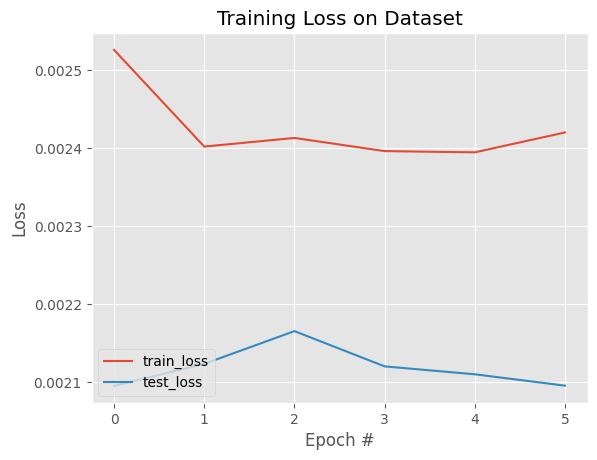

In [ ]:
plt.style.use("ggplot")
plt.figure()
plt.plot(H["train_loss"], label="train_loss")
plt.plot(H["val_loss"], label="test_loss")
plt.title("Training Loss on Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="lower left")
#plt.savefig(PLOT_PATH)
torch.save(model.state_dict(), MODEL_PATH)

In [ ]:
from prediction import make_predictions

In [ ]:
print("[INFO] loading up test image paths...")
imagePaths = open(TEST_PATHS).read().strip().split("\n")
imagePaths = np.random.choice(imagePaths, size=1)
# load our model from disk and flash it to the current device
print("[INFO] load up model...")
model_p = torch.load(MODEL_PATH).to(DEVICE)
# iterate over the randomly selected test image paths
for path in imagePaths:
	# make predictions and visualize the results
	make_predictions(model_p, path,rgb_mask_path,input_transform)

[INFO] loading up test image paths...
[INFO] load up model...


TypeError: ignored

#### orijinal masklar RGB olanlardan alınacak. Predict olanlar RGB'ye çevirilecek
#### earlystopping ayarlanacak.

In [ ]:

evalImagePaths = open(TEST_PATHS).read().strip().split("\n")
iou=0
for path in evalImagePaths:
	iou+=IOU(unet,path,masked_path)

print("IOU",iou/623)

NameError: name 'IOU' is not defined